## Step 0 — Load libraries

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

%matplotlib inline

## Step 1 — Load the Dataset

In [129]:
df = pd.read_csv('king_county_houses_aa.csv')
print(f'Dataset shape: {df.shape}')

Dataset shape: (21613, 21)


In [130]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Step 2 — Explore the Data

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [132]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [133]:
print(f'\nDuplicates {df.duplicated().sum()}')


Duplicates 0


No missing values, no null values, no duplicates

In [134]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21613.0,NaN,NaN,NaN,4580301520.864988,2876565571.312057,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0
date,21613,372,20140623T000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21613.0,NaN,NaN,NaN,540088.141767,367127.196483,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,NaN,NaN,NaN,3.370842,0.930062,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,NaN,NaN,NaN,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,NaN,NaN,NaN,2079.899736,918.440897,290.0,1427.0,1910.0,2550.0,13540.0
sqft_lot,21613.0,NaN,NaN,NaN,15106.967566,41420.511515,520.0,5040.0,7618.0,10688.0,1651359.0
floors,21613.0,NaN,NaN,NaN,1.494309,0.539989,1.0,1.0,1.5,2.0,3.5
waterfront,21613.0,NaN,NaN,NaN,0.007542,0.086517,0.0,0.0,0.0,0.0,1.0
view,21613.0,NaN,NaN,NaN,0.234303,0.766318,0.0,0.0,0.0,0.0,4.0


## Step 3 — Clean the Dataset

In [135]:
df['date'] = pd.to_datetime(df['date'])
df['year_sold']  = df['date'].dt.year
df['month_sold'] = df['date'].dt.month
df['day_sold']   = df['date'].dt.day

In [136]:
df.shape

(21613, 24)

In [137]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year_sold,month_sold,day_sold
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,13
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,9
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,25
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,9
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,18


## Step 4 — Split into Features (X) and Target (y)

In [138]:
y = df['price']
X = df.drop(columns=['price', 'id', 'date'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [139]:
print(f'X: {X.shape}  y: {y.shape}')
print(f'Train: {X_train.shape[0]}  Test: {X_test.shape[0]}')

X: (21613, 21)  y: (21613,)
Train: 17290  Test: 4323


## Step 5 — Explore Correlations

In [140]:
corr = X_train.copy()
corr['price'] = y_train.values
corr_matrix = corr.corr(numeric_only=True)

price_corr = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)
print('prices of top 10 corr')
print(price_corr.head(10))

prices of top 10 corr
sqft_living      0.701701
grade            0.665093
sqft_above       0.603255
sqft_living15    0.582667
bathrooms        0.526618
view             0.392108
sqft_basement    0.321387
lat              0.310770
bedrooms         0.308262
floors           0.253425
Name: price, dtype: float64


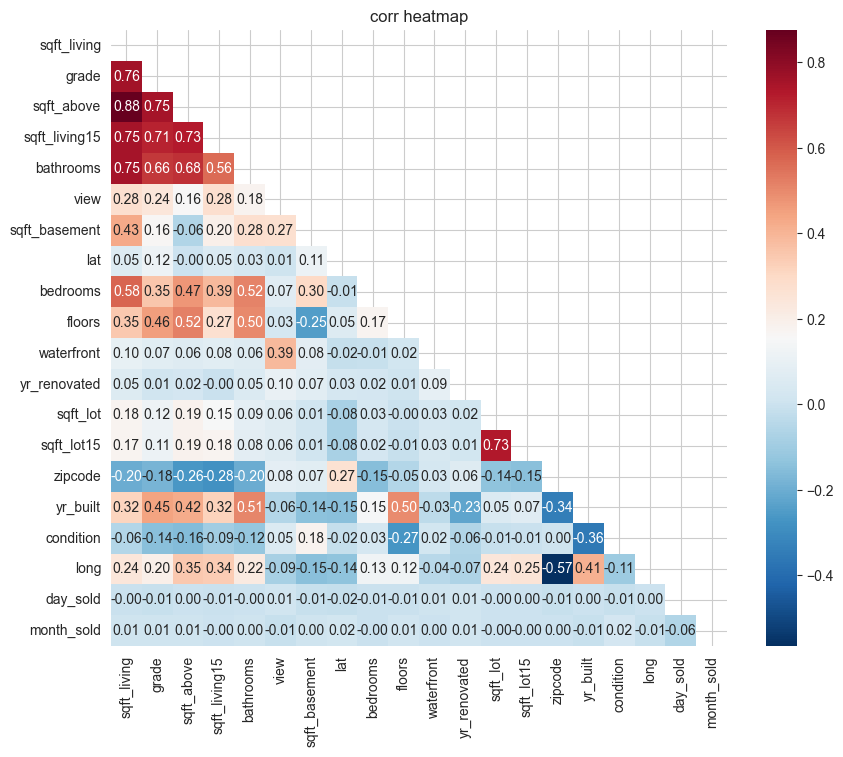

In [141]:
top = price_corr.head(20).index.tolist()
mask = np.triu(np.ones_like(corr_matrix.loc[top, top], dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[top, top], annot=True, fmt='.2f', cmap='RdBu_r', square=True, mask=mask)
plt.title('corr heatmap')
plt.show()

## Step 6 — Handle Categorical Variables (Encoding)

In [142]:
X_train_encoded = X_train.astype(float)
X_test_encoded = X_test.astype(float)

## Step 7 — Train Baseline Models

collect the models

In [143]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns)

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(alpha=1.0, max_iter=2000, random_state=42),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=50, learning_rate=1.0, random_state=42), }


In [144]:
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

## Step 8 — Evaluate Models (R², MAE, RMSE)

In [145]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({'Model': name, 'R² Test': round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2), })

results_df = pd.DataFrame(results).sort_values('R² Test', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


            Model  R² Test       MAE      RMSE
Gradient Boosting   0.8536  80962.10 148754.92
    Random Forest   0.8384  79999.22 156294.89
              KNN   0.7650 100313.94 188476.75
    Decision Tree   0.7346  97214.50 200290.56
            Ridge   0.7027 126927.12 212018.32
            Lasso   0.7027 126929.05 212017.76
Linear Regression   0.7027 126929.17 212017.67
         AdaBoost   0.2368 298637.29 339675.15


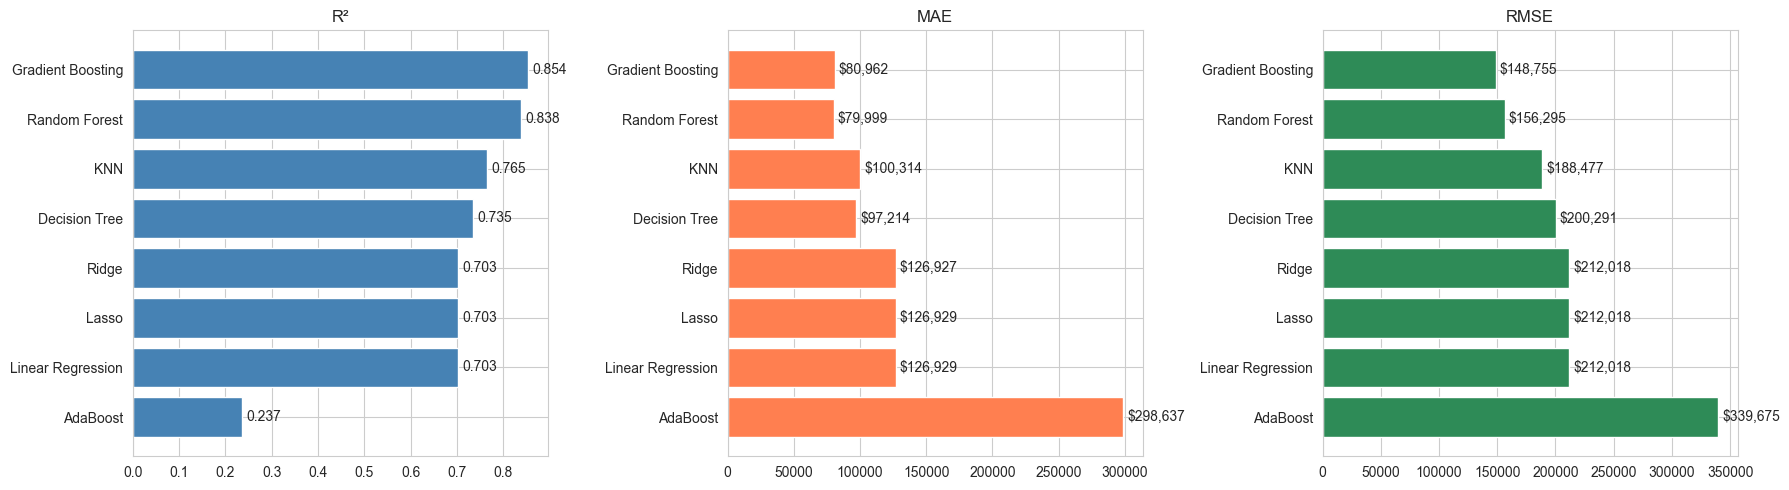

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color, title, fmt in zip(axes,
    ['R² Test', 'MAE', 'RMSE'], ['steelblue', 'coral', 'seagreen'], ['R²', 'MAE', 'RMSE'], ['{:.3f}', '${:,.0f}', '${:,.0f}']):

    ax.barh(results_df['Model'], results_df[col], color=color)
    ax.set_title(title)
    ax.invert_yaxis()
    for i, v in enumerate(results_df[col]):
        ax.text(v + max(results_df[col]) * 0.01, i, fmt.format(v), va='center')

plt.tight_layout()
plt.show()

In [153]:
best = results_df.iloc[0]
print(f"\nBest model {best['Model']}  |  R² = {best['R² Test']}  |  MAE = ${best['MAE']:,.0f}")


Best model Gradient Boosting  |  R² = 0.8536  |  MAE = $80,962


## Step 9 — Improve your models
    - Data side: handle outliers, multicollinearity, feature selection, normalization/standardization, feature engineering, etc.
    - Model side: try other models (especially ensemble methods) and perform hyperparameter tuning

## Step 10 — Compare all models and select the best one

## Step 11 — Identify which features most strongly influence house prices based on your best model

## Conclusions